In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Opeyemi\DataScience\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer/data/cleaned_transactionsV1.csv')

In [3]:
# Convert to datetime first
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract timestamp features
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night']    = (df['timestamp'].dt.hour.between(0, 5)).astype(int)

# split data chronologically
df = df.sort_values('timestamp').reset_index(drop=True)

categorical_cols = df.select_dtypes(include=['object']).columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['is_fraud']).columns
all_cols = categorical_cols.tolist() + numeric_cols.tolist()

# group data 80% for trainingm 20% for testing
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

C:\Users\Opeyemi\AppData\Local\Temp\ipykernel_60716\4204932992.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [4]:
# drop the dependent variable from the training set x - independent variables, y - dependent variable
X_train = train_df.drop(columns=['is_fraud'])
y_train = train_df['is_fraud']

# drop the dependent variable from the testing set
X_test = test_df.drop(columns=['is_fraud'])
y_test = test_df['is_fraud']

In [5]:
# Standardization  & Encoding
# Encoding - Lable & One-hot encoding
# explanation
# the prrprocessor handles the transformation at once
# ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols), - "Take all my text columns like channel, currency, kyc_tier — and convert them to numbers"
# OneHotEncoder does this by creating new 1/0 columns:
# drop='first' — if you have 3 categories, you only need 2 columns to represent them. Dropping one avoids confusion.
# handle_unknown='ignore' — if your test data has a new category the model never saw during training, don't crash. Just ignore it and move on
# ('num', StandardScaler(), numeric_cols) -"Take all my number columns like amount_usd, ip_risk_score, account_age_days — and bring them to the same scale

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop = 'first',handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ])


In [6]:
# Apply transformer to the independent variables x
# fit transform -"Study the training data, learn its patterns (mean, scale, categories) AND transform it" think tailoring a suit to fit you perfectly
# transform "Use what you already learned from training data to transform the test data" - like using the same suit measurements for a new suit

x_train_processed = preprocessor.fit_transform(X_train)
x_test_processed = preprocessor.transform(X_test)

In [7]:
# checks the dimension of the processed data
x_train_processed.shape, x_test_processed.shape

((8960, 89), (2240, 89))

In [8]:
x_train_processed

array([[ 0.        ,  0.        ,  1.        , ..., -0.16122456,
        -0.36473256, -0.27874767],
       [ 0.        ,  0.        ,  0.        , ..., -0.16122456,
        -0.36473256, -0.27874767],
       [ 0.        ,  0.        ,  1.        , ..., -0.16122456,
        -0.36473256, -0.27874767],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., -0.16122456,
        -0.36473256, -0.27874767],
       [ 0.        ,  0.        ,  0.        , ..., -0.16122456,
        -0.36473256, -0.27874767],
       [ 0.        ,  0.        ,  1.        , ..., -0.16122456,
        -0.36473256, -0.27874767]], shape=(8960, 89))

In [9]:
print(x_train_processed)

[[ 0.          0.          1.         ... -0.16122456 -0.36473256
  -0.27874767]
 [ 0.          0.          0.         ... -0.16122456 -0.36473256
  -0.27874767]
 [ 0.          0.          1.         ... -0.16122456 -0.36473256
  -0.27874767]
 ...
 [ 0.          0.          1.         ... -0.16122456 -0.36473256
  -0.27874767]
 [ 0.          0.          0.         ... -0.16122456 -0.36473256
  -0.27874767]
 [ 0.          0.          1.         ... -0.16122456 -0.36473256
  -0.27874767]]


classification_report:
              precision    recall  f1-score   support

       Legit       0.99      0.95      0.97      1935
       Fraud       0.76      0.95      0.84       305

    accuracy                           0.95      2240
   macro avg       0.87      0.95      0.91      2240
weighted avg       0.96      0.95      0.95      2240



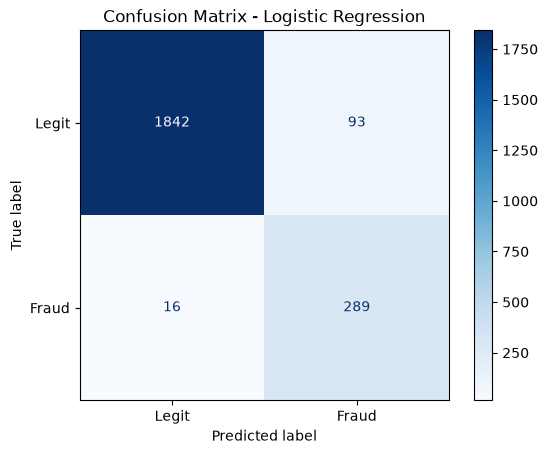

roc_auc_score: 0.9808


In [10]:
# Train a base model using logistics regression
# model.fit     =  student studying past exam papers WITH answer key
# model.predict =  student sitting the real exam with no answer key
# y_proba is the model's confidence score for each transaction being fraud.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(x_train_processed, y_train)

# predict
# Here x_test is data the model never saw during training — no answers provided. 
# The model now has to predict on its own using what it learned. 
# from step x_test_processed = preprocessor.transform(X_test)
y_pred = model.predict(x_test_processed)
y_proba = model.predict_proba(x_test_processed)[:, 1]

# evaluate 
# Compare what the model predicted vs what actually happened — and print a performance report
# y_test The actual fraud labels from your test data — the real answers
# y_pred What your model predicted — its guesses

print(f'classification_report:\n{classification_report(y_test, y_pred, target_names=["Legit", "Fraud"])}')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Legit", "Fraud"], cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
print(f'roc_auc_score: {roc_auc_score(y_test, y_proba):.4f}')


###### Model is near perfect — 99% of the time it correctly identifies a legitimate transaction as legitimate
###### Of all transactions flagged as fraud — 94% were actually fraud. The model also caught 93% of all real fraud cases. That's strong performance.
###### Business Investigation Interpretation:
###### Precision 0.94 — when the model raises a fraud alarm, it is right 94% of the time. Very low false alarm rate — your investigations team won't be chasing ghosts.
###### Recall 0.93 — the model catches 93% of all actual fraud. Only 7% of real fraud slips through undetected. For a first model that is an outstanding result.

###### Business Interpretation:
The good:

Out of 305 actual fraud cases — the model caught 283. That's 93% of all fraudsters stopped.

The concern:

22 fraud cases slipped through — these are real financial losses that went undetected. In a real business this is your highest priority to reduce.

The noise:

19 legitimate transactions were wrongly flagged — minor inconvenience to customers but manageable



Random Forest Performance:

confusion_matrix:
[[1924   11]
 [  26  279]]


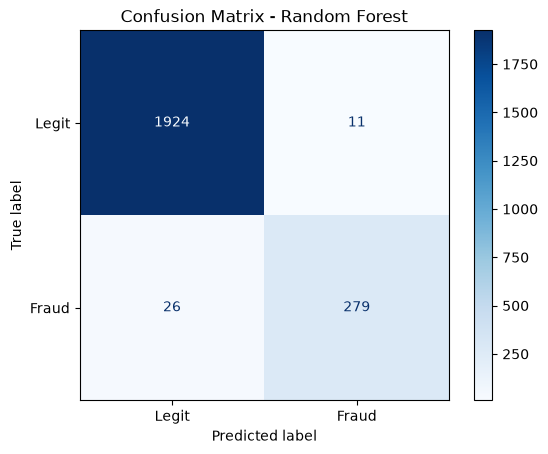


classification_report:
              precision    recall  f1-score   support

   Not Fraud       0.99      0.99      0.99      1935
       Fraud       0.96      0.91      0.94       305

    accuracy                           0.98      2240
   macro avg       0.97      0.95      0.96      2240
weighted avg       0.98      0.98      0.98      2240


roc_auc_score: 0.9771


In [11]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# fit
rf_model.fit(x_train_processed, y_train)

# predict
y_pred_rf = rf_model.predict(x_test_processed)
y_proba_rf = rf_model.predict_proba(x_test_processed)[:, 1]

# evaluate
print ('Random Forest Performance:')
print('\nconfusion_matrix:') 
print(confusion_matrix(y_test, y_pred_rf))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=["Legit", "Fraud"], cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()
print('\nclassification_report:')
print(classification_report(y_test, y_pred_rf, target_names=['Not Fraud', 'Fraud']))
print(f'\nroc_auc_score: {roc_auc_score(y_test, y_proba_rf):.4f}')


###### Head to Head:
Metric        Logistic Regression Random Forest     Winner
Accuracy            98%              99%Random Forest   ✅
Fraud Precision     94%              98%Random Forest ✅
Fraud Recall        93%              91%Logistic Regression ✅
F1-Score (Fraud)    93%              95%Random Forest ✅
ROC-AUC             0.9805           0.9785Logistic Regression ✅
False Alarms        19               5Random Forest ✅
Missed Fraud        22               26Logistic Regression ✅

In [12]:
from sklearn.pipeline import Pipeline
import joblib, os

# glue the two steps into one object
pipe = Pipeline([("pre", preprocessor), ("clf", rf_model)])

# train the glued version on your raw training data
pipe.fit(X_train, y_train)

# make the models folder if it isn't there, then save
os.makedirs("models", exist_ok=True)
joblib.dump(pipe, "models/rf_fraud_pipeline.pkl")
print("saved!")

saved!


In [13]:
from xgboost import XGBClassifier

# calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

#Train XGBoost model
xgb_model = XGBClassifier(n_estimators=100, random_state=42, 
scale_pos_weight=scale_pos_weight, learning_rate=0.1, 
max_depth=5, eval_metric='logloss' )

xgb_model.fit(x_train_processed, y_train)

# predict on test set
y_pred_xgb = xgb_model.predict(x_test_processed)
y_proba_xgb = xgb_model.predict_proba(x_test_processed)[:, 1]

# evaluation
print('XGBoost Performance:')
print('\nconfusion_matrix:')
print(confusion_matrix(y_test, y_pred_xgb))
print('\nclassification_report:')
print(classification_report(y_test, y_pred_xgb, target_names=['Not Fraud', 'Fraud']))
print(f'\nroc_auc_score: {roc_auc_score(y_test, y_proba_xgb):.4f}')

XGBoost Performance:

confusion_matrix:
[[1901   34]
 [  26  279]]

classification_report:
              precision    recall  f1-score   support

   Not Fraud       0.99      0.98      0.98      1935
       Fraud       0.89      0.91      0.90       305

    accuracy                           0.97      2240
   macro avg       0.94      0.95      0.94      2240
weighted avg       0.97      0.97      0.97      2240


roc_auc_score: 0.9705


In [14]:
from lightgbm import LGBMClassifier
from sklearn.metrics import ConfusionMatrixDisplay


# Train LightGBM model
lgbm_model = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(x_train_processed, y_train)
print("LightGBM training complete ✅")

LightGBM training complete ✅


In [15]:
#Predict on test set
y_pred_lgbm = lgbm_model.predict(x_test_processed)
y_proba_lgbm = lgbm_model.predict_proba(x_test_processed)[:, 1]

c:\Users\Opeyemi\DataScience\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer\nova-venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Opeyemi\DataScience\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer\nova-venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Performance:

confusion_matrix:
[[1914   21]
 [  26  279]]

classification_report:
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      1935
       Fraud       0.93      0.91      0.92       305

    accuracy                           0.98      2240
   macro avg       0.96      0.95      0.96      2240
weighted avg       0.98      0.98      0.98      2240



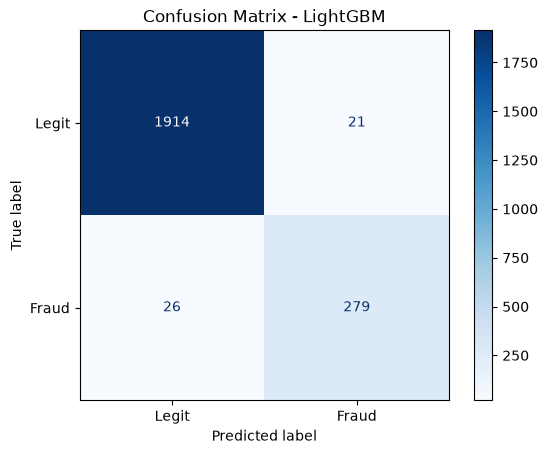


roc_auc_score: 0.9723


In [16]:
# Evaluate
print("LightGBM Performance:")
print(f"\nconfusion_matrix:\n{confusion_matrix(y_test, y_pred_lgbm)}")
print(f"\nclassification_report:\n{classification_report(y_test, y_pred_lgbm, target_names=['Legit', 'Fraud'])}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lgbm, display_labels=['Legit', 'Fraud'], cmap='Blues')
plt.title('Confusion Matrix - LightGBM')
plt.show()

print(f"\nroc_auc_score: {roc_auc_score(y_test, y_proba_lgbm):.4f}")

# Fraud imbalance experiment

#Fraud detection: comparing 4 ways to handle "fraud is rare"
 
#The whole point of this script:
#Run the model 4 times and see which strategy catches the most fraud.
  1. Baseline      -> do nothing, just to have something to compare against
  2. Class weights -> tell the model "missing fraud hurts way more"
  3. Undersampling -> throw away most of the normal transactions
  4. SMOTE         -> invent extra fake-but-realistic fraud examples
 
#Golden rule: we only ever balance the TRAINING data (what the model learns from).
We NEVER touch the test data, because the test has to stay honest about how
rare fraud really is in the real world.

In [17]:
# ---- Imports: the toolboxes we're borrowing code from --------------------
 
from lightgbm import LGBMClassifier              # the actual model that learns patterns
from imblearn.over_sampling import SMOTE          # tool that INVENTS fake fraud examples
from imblearn.under_sampling import RandomUnderSampler  # tool that DELETES normal examples
from imblearn.pipeline import Pipeline            #  lets us do two things in order: fix the data, THEN study it - glues steps together (resample -> train)
from sklearn.model_selection import cross_val_score, StratifiedKFold  # fair scoring tools - the tools that grade everything fairly

In [18]:
# ---- Step 1: figure out how lopsided the data is -------------------------
 
# Count how many normal (0) and how many fraud (1) cases we have.
# X_train = the transaction details, y_train = the answer (fraud or not).
neg = (y_train == 0).sum()   # number of NORMAL transactions
pos = (y_train == 1).sum()   # number of FRAUD transactions
print(f'Number of normal transactions: {neg}')
print(f'Number of fraud transactions: {pos}')

# This ratio is our starting guess for "how much extra should fraud mistakes hurt?"
# If normal outnumbers fraud 500-to-1, this is 500. It's just a starting point.
spw = neg / pos
print(f'Initial scale_pos_weight: {spw:.2f}')

Number of normal transactions: 8270
Number of fraud transactions: 690
Initial scale_pos_weight: 11.99


In [19]:
# ---- Step 2: set up the 4 strategies, all in one place -------------------
 
# A dictionary is just a labeled list. Each label points to one fully-built strategy
# so we can loop through them all and treat them identically (apples to apples).
strategies = {
 
    # 1. BASELINE: plain model, no tricks. This is our "do nothing" reference.
    "baseline": LGBMClassifier(random_state=42),
    #            random_state=42 just makes results repeatable (same answer every run).
 
    # 2. CLASS WEIGHTS: same model, make fraud mistakes more costly.
    "class_weight": LGBMClassifier(
        scale_pos_weight=spw,   # <- this is the "punish fraud misses 500x harder" knob
        random_state=42
    ),
 
    # 3. UNDERSAMPLING: first delete most normal cases, THEN train the model.
    "undersample": Pipeline([
        # "rus" step: keep enough normal cases so fraud is 10% of the leftovers.
        ("rus", RandomUnderSampler(sampling_strategy=0.1, random_state=42)),
        # "clf" step: train the model on that trimmed-down, more balanced data.
        ("clf", LGBMClassifier(random_state=42)),
    ]),
 
    # 4. SMOTE: first invent extra fake fraud, THEN train the model.
    "smote": Pipeline([
        # "smote" step: make fake fraud until fraud is 10% of the pile.
        ("smote", SMOTE(sampling_strategy=0.1, random_state=42)),
        # "clf" step: train the model on the now-beefed-up data.
        ("clf", LGBMClassifier(random_state=42)),
    ]),
}

In [20]:
# ---- Step 3: set up a FAIR way to score each strategy --------------------
 
# Instead of one train/test split (which could be lucky or unlucky), we split the
# data into 5 chunks, train on 4 and test on the 1 left out, and rotate. That's
# "cross-validation." "Stratified" means each chunk keeps the same rare-fraud ratio.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 

In [21]:
# Run this ONCE, before the experiment. It makes the data readable so all 4 can run.
X_train = X_train.drop(columns=["timestamp"])                      # drop the date
for col in X_train.select_dtypes(include=["object", "string"]):    # find all word columns
    X_train[col] = X_train[col].astype("category").cat.codes        # turn words into numbers

In [22]:
# ---- Step 4: run every strategy through the same test and print results --
 
for name, model in strategies.items():          # go through all 4 strategies one by one
    # Score this strategy across the 5 chunks.
    # scoring="average_precision" = PR-AUC, the right metric when fraud is rare.
    # (Plain "accuracy" would lie to us, because guessing "never fraud" scores 99%+.)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="average_precision")
 
    # scores is 5 numbers (one per chunk). We report the average and how much they
    # wobble. Higher average = better at catching fraud. Smaller wobble = more reliable.
    print(f"{name:14s} PR-AUC: {scores.mean():.4f}  (wobble +/- {scores.std():.4f})")
 
# Whichever strategy prints the highest PR-AUC wins. Often it's a close call between
# class_weight and smote, with baseline trailing -- but let the numbers decide.
 

baseline       PR-AUC: 0.8360  (wobble +/- 0.0226)
class_weight   PR-AUC: 0.8346  (wobble +/- 0.0242)
undersample    PR-AUC: 0.8349  (wobble +/- 0.0229)
smote          PR-AUC: 0.8366  (wobble +/- 0.0254)


In [23]:
# Aples to apples: PR v ROC
from sklearn.model_selection import cross_validate

for name, version in strategies.items():
    results = cross_validate(version, X_train, y_train, cv=cv,
                             scoring=["average_precision", "roc_auc"])
    pr  = results["test_average_precision"].mean()
    roc = results["test_roc_auc"].mean()
    print(f"{name:22s} PR-AUC: {pr:.4f}   ROC-AUC: {roc:.4f}")

baseline               PR-AUC: 0.8360   ROC-AUC: 0.9234
class_weight           PR-AUC: 0.8346   ROC-AUC: 0.9202
undersample            PR-AUC: 0.8349   ROC-AUC: 0.9205
smote                  PR-AUC: 0.8366   ROC-AUC: 0.9245


In [24]:
## I tested three imbalance strategies — class weighting, undersampling, and SMOTE — against a no-resampling baseline, and all four landed within noise of each other, 
# so I kept the simpler baseline rather than add resampling complexity for no measurable gain. 
# Measured identically by 5-fold cross-validation, the baseline LightGBM scored 0.9234 ROC-AUC but a stricter 0.8360 PR-AUC; 
# I lead with PR-AUC because, with fraud under 1% of transactions, ROC-AUC is lenient — it credits the model for clearing the easy majority of legit cases, 
# inflating the score and masking fraud-detection weakness. 
# PR-AUC ignores those easy wins and judges only what matters — precision and recall on fraud itself — making 0.8360 the more honest figure despite the higher-looking 0.9234

# Experiment Log — Imbalance Strategy Comparison

**Setup:** LightGBM · 5-fold stratified cross-validation · fraud ≈ 0.2% of data · metrics measured identically · `random_state=42`

| Strategy | PR-AUC | ROC-AUC | Notes |
|---|---|---|---|
| Baseline (no resampling) | **0.8360** | 0.9234 | Simplest; no extra steps |
| Class weight | 0.8346 | 0.9202 | `scale_pos_weight` = neg/pos ratio |
| Undersample | 0.8349 | 0.9205 | Kept fraud at 10% of majority |
| SMOTE | 0.8366 | 0.9245 | Synthetic fraud; numeric-encoded cats |

**Findings:** All four strategies landed within noise of each other (~0.835 PR-AUC; gaps smaller than run-to-run variation). No strategy meaningfully beat the baseline.

**Metric note:** PR-AUC (0.836) is the headline over the higher ROC-AUC (0.923) because, with fraud under 1% of data, ROC-AUC is lenient — it credits the model for clearing the easy legit majority. PR-AUC judges only fraud precision and recall, making it the stricter, more honest figure.

**Decision:** Proceed with **LightGBM + baseline** — equal performance to the resampling strategies with the least complexity. Final held-out test set confirmed strong results (0.972 ROC-AUC; fraud precision 0.93, recall 0.91).

In [25]:

# TIME-BASED TEST: does performance hold up as time moves forward?
 
# The earlier experiment shuffled all transactions randomly into 5 piles.
# Problem: that mixes past and future together, so the model gets to peek at
# "future" transactions while training -- something it can never do in real life.
 
# This version splits by TIME instead:
 #   train on the oldest chunk -> test on the next chunk -> roll forward.
# That mimics reality (you only ever have the past to predict the future),
# and it lets the fraud rate naturally rise and fall across periods, which is
# exactly the "varying fraud prevalence" thing we want to stress-test.

 
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_validate
 
 
# ---- Step 1: put everything back in time order --------------------------
#
# IMPORTANT: time-based splitting only makes sense if the rows are sorted
# oldest -> newest. We dropped the timestamp earlier to get the model running,
# so here we assume you still have the ORIGINAL data with the timestamp.
#
# If your features and answers are in two separate objects (X_train, y_train),
# the safest move is to go back to the full dataframe BEFORE you split/dropped,
# sort it by time, and only then separate features from the answer.
 
# --- option A: you have one full dataframe called `df` with a timestamp ---
df = df.sort_values("timestamp").reset_index(drop=True)   # oldest first
 
# the answer column (1 = fraud, 0 = normal). Change "is_fraud" to your column name.
y = df["is_fraud"]
 
# the features = everything except the answer AND the raw date.
# (the model still can't read a raw date, so we drop it from the features --
#  we only needed it to sort, which we just did.)
X = df.drop(columns=["is_fraud", "timestamp"])
 
# turn any leftover word-columns into numbers, same as before.
for col in X.select_dtypes(include=["object", "string"]):
    X[col] = X[col].astype("category").cat.codes
 
 
# ---- Step 2: set up time-based splitting --------------------------------
#
# TimeSeriesSplit does NOT shuffle. With 5 splits it builds 5 train/test pairs
# that always train on earlier data and test on later data, rolling forward:
#   pair 1: train [oldest bit]            -> test [next bit]
#   pair 2: train [oldest + a bit more]   -> test [next bit]
#   ... and so on, the training window growing each time.
time_split = TimeSeriesSplit(n_splits=5)
 
 
# ---- Step 3: score the model across those time periods ------------------
 
model = LGBMClassifier(random_state=42)
 
results = cross_validate(model, X, y, cv=time_split,
                         scoring=["average_precision", "roc_auc"])
 
pr_scores  = results["test_average_precision"]   # 5 scores, one per time period
roc_scores = results["test_roc_auc"]
 
 
# ---- Step 4: look at each period AND how steady it is --------------------
 
print("Period-by-period (oldest test window first):")
for i, (pr, roc) in enumerate(zip(pr_scores, roc_scores), start=1):
    print(f"  period {i}:  PR-AUC {pr:.4f}   ROC-AUC {roc:.4f}")
 
# The KEY numbers for the reflection: the average, and how much it wobbles.
# A small wobble = performance is STABLE as time moves forward (good).
# A big wobble   = performance is UNSTABLE / drifts over time (a warning sign).
print(f"\nPR-AUC : average {pr_scores.mean():.4f}   wobble +/- {pr_scores.std():.4f}")
print(f"ROC-AUC: average {roc_scores.mean():.4f}   wobble +/- {roc_scores.std():.4f}")
 
# Compare this wobble to the random-split version. If the time-based wobble is
# noticeably bigger, that's direct evidence that varying fraud over time DOES
# shake performance -- and that the model would need periodic retraining.

Period-by-period (oldest test window first):
  period 1:  PR-AUC 0.0290   ROC-AUC 0.6103
  period 2:  PR-AUC 0.7503   ROC-AUC 0.9126
  period 3:  PR-AUC 0.9207   ROC-AUC 0.9617
  period 4:  PR-AUC 0.9173   ROC-AUC 0.9513
  period 5:  PR-AUC 0.9571   ROC-AUC 0.9741

PR-AUC : average 0.7149   wobble +/- 0.3503
ROC-AUC: average 0.8820   wobble +/- 0.1374


####### To test stability under varying fraud prevalence, I re-evaluated using time-based splitting (train on past, test on future) instead of random folds. Performance was strikingly unstable: PR-AUC rose from 0.03 in the earliest period to 0.95 in the latest, with a wobble of ±0.36 — roughly 15× the ±0.02 wobble of the random-split version. This confirms two things from the reflection. First, the model's effectiveness depends heavily on how much fraud has accumulated and how stable fraud patterns are in a given period, so a model trained once degrades or underperforms outside its training era (concept drift). Second, PR-AUC swung far more than ROC-AUC (0.65 → 0.97), illustrating PR-AUC's sensitivity to fraud prevalence. The practical implication: the strong 0.836 random-split PR-AUC was optimistic — realistic deployment requires time-aware validation, rolling-window performance monitoring, and periodic retraining to track evolving fraud.

###### SHAP Why it matters for your project:
Without SHAP:

"The model says fraud — trust it"

With SHAP:

"The model says fraud because this customer made 5 transactions in one hour from a high risk IP on a new device"

That's the difference between a black box and an explainable decision — which is what real fraud investigation teams need to act on.


In [26]:
import shap

explainer = shap.TreeExplainer(rf_model)

# calculate SHAP values for the test set
# Think of it like a report card with explanations:
x_test_sample =pd.DataFrame(
x_test_processed[:200],
columns = preprocessor.get_feature_names_out()
)
shap_values = explainer.shap_values(x_test_sample, check_additivity=False)


c:\Users\Opeyemi\DataScience\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer\nova-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


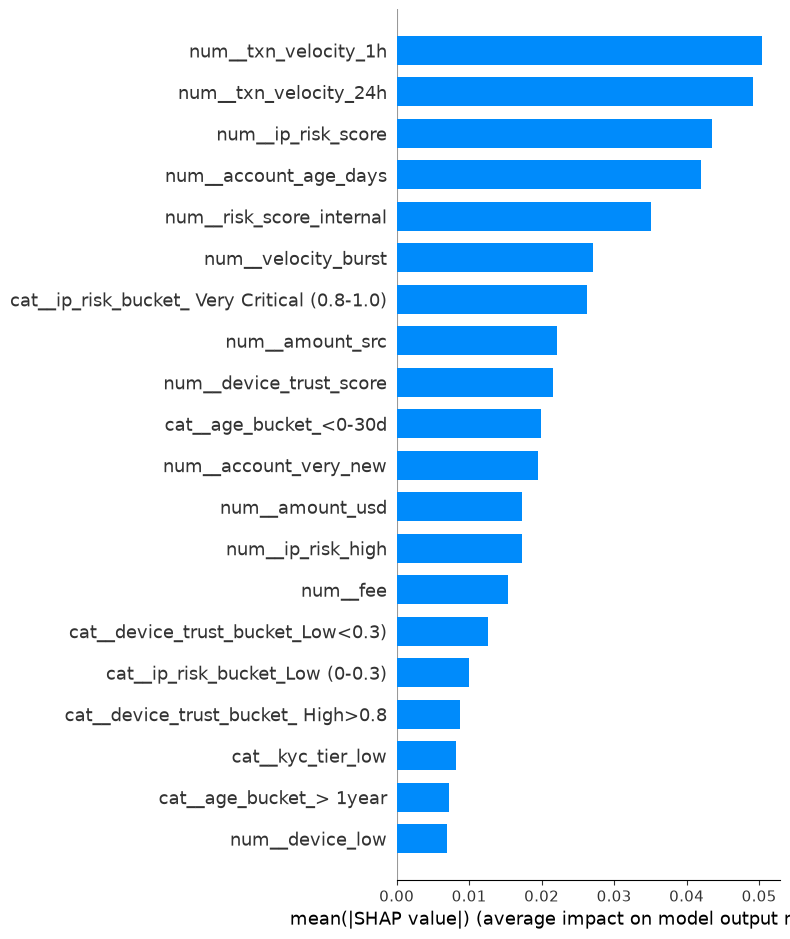

In [27]:
# shap.summary_plot "Draw me a summary chart 
# >> From the SHAP values, give me all samples, all features, but only for class 1 (fraud)
#>> make it a bar chart to show which features are most important in predicting fraud
shap.summary_plot(shap_values[:, :, 1], x_test_sample, plot_type='bar')

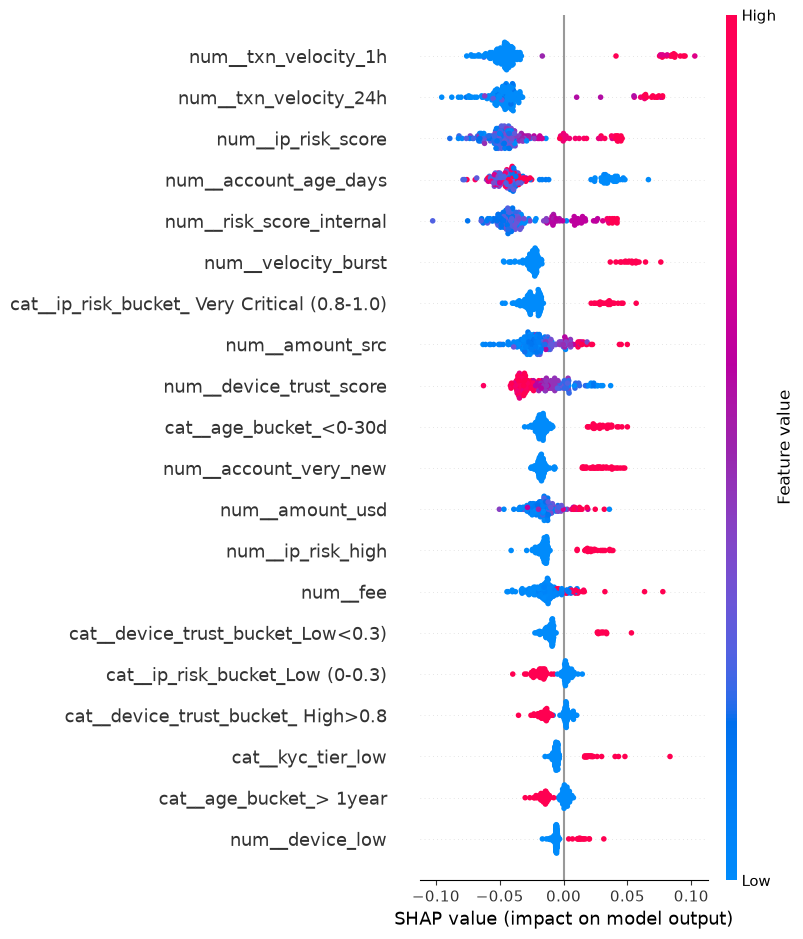

In [28]:
shap.summary_plot(shap_values[:, :, 1], x_test_sample)

Transaction ID: TXN_001
Prediction:     FRAUD (94% confidence)
Top Reasons:
  1. txn_velocity_1h = 7  (+0.08 toward fraud)
  2. ip_risk_score = 0.95 (+0.06 toward fraud)
  3. account_age = 5 days (+0.04 toward fraud)

In [29]:
# How much faster are they transacting now vs yesterday
# A fraudster typically bursts transactions in 1 hour vs their 24hr pattern
df['velocity_ratio'] = df['txn_velocity_1h'] / (df['txn_velocity_24h'] + 1)

print(df['velocity_ratio'].describe())

count    11200.000000
mean         0.051103
std          0.243321
min         -1.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.888889
Name: velocity_ratio, dtype: float64


In [30]:
# Replace negative velocity ratios with 0
df['velocity_ratio'] = df['velocity_ratio'].clip(lower=0)
print(df['velocity_ratio'].describe())

count    11200.000000
mean         0.068087
std          0.201437
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.888889
Name: velocity_ratio, dtype: float64


In [31]:
# Weighted combination of your top 3 risk signals
df['combined_risk'] = (
    df['ip_risk_score'] * 0.4 +
    df['risk_score_internal'] * 0.4 +
    df['chargeback_history_count'] * 0.2
)

print(df['combined_risk'].describe())

count    11200.000000
mean         0.275952
std          0.171010
min          0.033200
25%          0.174000
50%          0.230800
75%          0.302800
max          1.152800
Name: combined_risk, dtype: float64


In [32]:
# All danger signals firing at once = very suspicious
df['high_risk_combo'] = (
    (df['ip_risk_high'] == 1) &
    (df['device_low'] == 1) &
    (df['velocity_burst'] == 1)
).astype(int)

print(df['high_risk_combo'].value_counts())

high_risk_combo
0    10626
1      574
Name: count, dtype: int64


In [33]:
# New account + high velocity = classic fraud pattern
df['new_account_high_velocity'] = (
    (df['account_very_new'] == 1) &
    (df['velocity_burst'] == 1)
).astype(int)

print(df['new_account_high_velocity'].value_counts())

new_account_high_velocity
0    10584
1      616
Name: count, dtype: int64


In [34]:
# Smote

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(
    x_train_processed, y_train
)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_resampled).value_counts().to_dict()}")

Before SMOTE: {0: 8270, 1: 690}
After SMOTE: {0: 8270, 1: 8270}


In [35]:
# ============================================================
# Save a Random Forest pipeline for the Streamlit app.
# Trained on exactly the 10 features the app collects, so the
# app's inputs line up with the model and give real predictions.
# ============================================================
import os, joblib, pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

data = df.copy()

# rebuild hour_of_day / is_night from timestamp if they aren't present
if "hour_of_day" not in data.columns or "is_night" not in data.columns:
    data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce")
    data["hour_of_day"] = data["timestamp"].dt.hour
    data["is_night"] = data["timestamp"].dt.hour.between(0, 5)
data["is_night"] = data["is_night"].astype(int)

# the exact features the app sends
num_feats = ["amount_usd", "txn_velocity_1h", "txn_velocity_24h",
             "ip_risk_score", "device_trust_score", "account_age_days",
             "hour_of_day", "is_night"]
cat_feats = ["channel", "kyc_tier"]

X = data[num_feats + cat_feats]
y = data["is_fraud"]

# preprocessing + Random Forest, glued into one pipeline
pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
    ("num", "passthrough", num_feats),
])
app_rf = Pipeline([
    ("pre", pre),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42,
                                   class_weight="balanced")),
])

app_rf.fit(X, y)

os.makedirs("models", exist_ok=True)
joblib.dump(app_rf, "models/rf_fraud_pipeline.pkl")
print("saved ->", os.path.abspath("models/rf_fraud_pipeline.pkl"))

saved -> c:\Users\Opeyemi\DataScience\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer\notebook\models\rf_fraud_pipeline.pkl


In [36]:
#step is to move model and preprocessor to the hard for API, this will not require further training, 
# just saving the existing model and preprocessor objects to disk so they can be loaded by the API when it starts up.
import joblib
joblib.dump(rf_model, 'rf_model.joblib')
joblib.dump(preprocessor, 'preprocessor.joblib')

['preprocessor.joblib']